In [1]:
! pip install python-doctr[torch]
! pip install tensorflow_addons
! pip install tf2onnx
! pip install --upgrade pillow==6.2.2
! pip install -e git+https://github.com/mindee/doctr.git#egg=python-doctr[torch]

  Using cached Pillow-6.2.2-cp310-cp310-linux_x86_64.whl
  Attempting uninstall: pillow
    Found existing installation: Pillow 10.0.1
    Uninstalling Pillow-10.0.1:
      Successfully uninstalled Pillow-10.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bokeh 3.2.2 requires pillow>=7.1.0, but you have pillow 6.2.2 which is incompatible.
dopamine-rl 4.0.6 requires Pillow>=7.0.0, but you have pillow 6.2.2 which is incompatible.
imageio 2.31.3 requires pillow>=8.3.2, but you have pillow 6.2.2 which is incompatible.
python-doctr 0.7.1a0 requires Pillow>=10.0.0, but you have pillow 6.2.2 which is incompatible.
weasyprint 59.0 requires Pillow>=9.1.0, but you have pillow 6.2.2 which is incompatible.


DEPRECATION: git+https://github.com/mindee/doctr.git#egg=python-doctr[torch] contains an egg fragment with a non-PEP 508 name pip 25.0 will enforce this behaviour change. A possible replacement is to use the req @ url syntax, and remove the egg fragment. Discussion can be found at https://github.com/pypa/pip/issues/11617
Obtaining python-doctr[torch] from git+https://github.com/mindee/doctr.git#egg=python-doctr[torch]
  Updating ./src/python-doctr clone
  Running command git fetch -q --tags
  Running command git reset --hard -q 28e5375c399ae5dd146a1b7e13bd5831acb6dc2d
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached Pillow-10.0.1-cp310-cp310-manylinux_2_28_x86_64.whl (3.6 MB)
  Building editable for python-doctr (pyproject.toml) ... done
  Created wheel for python-doctr: filename=python_doctr-0.7.1a0-0.editable-py3

In [2]:
import torch
import os
from doctr.models import ocr_predictor
from collections import OrderedDict
from doctr.io import DocumentFile
import cv2
import json
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import ast
import matplotlib.pyplot as plt
import math
from scipy.stats import gaussian_kde
import networkx as nx

In [3]:
def doctr_predictions(directory):

    doc = DocumentFile.from_images(directory)
    result = predictor(doc)
    dic = result.export()

    page_dims = [page['dimensions'] for page in dic['pages']]

    regions = []
    abs_coords = []

    regions = [[word for block in page['blocks'] for line in block['lines'] for word in line['words']] for page in dic['pages']]
    abs_coords = [
    [[int(round(word['geometry'][0][0] * dims[1])),
      int(round(word['geometry'][0][1] * dims[0])),
      int(round(word['geometry'][1][0] * dims[1])),
      int(round(word['geometry'][1][1] * dims[0]))] for word in words]
    for words, dims in zip(regions, page_dims)
    ]

    return abs_coords

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
predictor = ocr_predictor(pretrained=True)

state_dict = torch.load("/content/db_resnet50.pt")

new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:]
    new_state_dict[name] = v


predictor.det_predictor.model.load_state_dict(new_state_dict)

  0%|          | 0/94178964 [00:00<?, ?it/s]

  0%|          | 0/58758994 [00:00<?, ?it/s]

RuntimeError: ignored

In [5]:
def calculate_center_points(df, new_df):
    top = []
    bottom = []
    left = []
    right = []
    id = []

    for i in range(0,len(df)):
      x1,y1,x2,y2 = df[0][i][0], df[0][i][1], df[0][i][2], df[0][i][3]
      top_center = [(x1 + x2) / 2, y1]
      bottom_center = [(x1 + x2) / 2, y2]
      left_center = [x1, (y1 + y2) / 2]
      right_center = [x2, (y1 + y2) / 2]
      top.append(top_center)
      bottom.append(bottom_center)
      left.append(left_center)
      right.append(right_center)
      id.append(i)
    new_df['Top'] = top
    new_df['Bottom'] = bottom
    new_df['Left'] = left
    new_df['Right'] = right
    new_df['Id'] = id

In [6]:
def euclidean_distance(point1, point2):
    squared_diff = (point1 - point2) ** 2
    sum_squared_diff = np.sum(squared_diff)
    distance = np.sqrt(sum_squared_diff)

    return distance

In [9]:
def parse_string(string, start_char, end_char):
    start_index = string.index(start_char) + 1
    end_index = string.index(end_char)
    parsed_string = string[start_index:end_index]
    return parsed_string

In [10]:
def calculate_rightbox(new_df,x):
    right = []
    for i in range(len(new_df)):
        dist = []
        id = []
        for j in range(len(new_df)):
            distance = euclidean_distance(np.array(new_df['Left'][j]), np.array(new_df['Right'][i]))
            y_distance = abs(new_df['Right'][i][1] - new_df['Left'][j][1])
            if 0 <= distance < x and i != j and y_distance < 20:
                dist.append(distance)
                id.append(j)
        if dist:
            t = np.argmin(dist)
            right.append([np.min(dist), id[t]])
        else:
            right.append([-1, 0])

    new_df['Right_Box'] = right

In [11]:
def calculate_leftbox(new_df,x):
    left = []
    for i in range(len(new_df)):
        dist = []
        id = []
        for j in range(len(new_df)):
            distance = euclidean_distance(np.array(new_df['Right'][j]), np.array(new_df['Left'][i]))
            y_distance = abs(new_df['Left'][i][1] - new_df['Right'][j][1])
            if 0 <= distance < x and i != j and y_distance < 20:
                dist.append(distance)
                id.append(j)
        if dist:
            t = np.argmin(dist)
            left.append([np.min(dist), id[t]])
        else:
            left.append([-1, 0])

    new_df['Left_Box'] = left

In [12]:
def calculate_topbox(new_df,y):
    top = []
    for i in range(len(new_df)):
        dist = []
        id = []
        for j in range(len(new_df)):
            distance = euclidean_distance(np.array(new_df['Bottom'][j]), np.array(new_df['Top'][i]))
            if 0 <= distance < y and i != j:
                dist.append(distance)
                id.append(j)
        if dist:
            t = np.argmin(dist)
            top.append([np.min(dist), id[t]])
        else:
            top.append([-1, 0])

    new_df['Top_Box'] = top

# Changed calculate_bottombox()

In [13]:
def calculate_bottombox(new_df,y):
    bottom = []
    for i in range(len(new_df)):
        dist = []
        id = []
        for j in range(len(new_df)):
            distance = euclidean_distance(np.array(new_df['Top'][j]), np.array(new_df['Bottom'][i]))
            if 0 <= distance < y and i != j:
                dist.append(distance)
                id.append(j)
        if dist:
            t = np.argmin(dist)
            bottom.append([np.min(dist), id[t]])
        else:
            bottom.append([-1, 0])

    new_df['Bottom_Box'] = bottom

In [14]:
def make_connections(image):

  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  image_with_boxes = image_rgb.copy()

  for index, row in euclidean.iterrows():
      left = int(row['Left'][0])
      right = int(row['Right'][0])
      top = int(row['Top'][1])
      bottom = int(row['Bottom'][1])
      box_id = int(row['Id'])

      width = right - left
      height = bottom - top

      top_left = (left, top)
      bottom_right = (right, bottom)

      cv2.rectangle(image_with_boxes, top_left, bottom_right, (255, 0, 0), 4)

      # label_position = (left, top - 10)
      # cv2.putText(image_with_boxes, str(box_id), label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

      top_adjacent_id = int(row['Top_Box'][1])
      bottom_adjacent_id = int(row['Bottom_Box'][1])
      left_adjacent_id = int(row['Left_Box'][1])
      right_adjacent_id = int(row['Right_Box'][1])

      if top_adjacent_id != 0:
          top_adjacent_row = euclidean[euclidean['Id'] == top_adjacent_id].iloc[0]
          top_adjacent_center = int(top_adjacent_row['Bottom'][0]) , int(top_adjacent_row['Bottom'][1])
          cv2.line(image_with_boxes, (int(left) + width // 2, int(top)), top_adjacent_center, (0, 255, 0), 4)

      if bottom_adjacent_id != 0:
          bottom_adjacent_row = euclidean[euclidean['Id'] == bottom_adjacent_id].iloc[0]
          bottom_adjacent_center = int(bottom_adjacent_row['Top'][0]) , int(bottom_adjacent_row['Top'][1])
          cv2.line(image_with_boxes, (int(left) + width // 2, int(bottom)), (int(bottom_adjacent_center[0]), int(bottom_adjacent_center[1])), (0, 255, 0), 4)

      if left_adjacent_id != 0:
          left_adjacent_row = euclidean[euclidean['Id'] == left_adjacent_id].iloc[0]
          left_adjacent_center = int(left_adjacent_row['Right'][0]) , int(left_adjacent_row['Right'][1])
          cv2.line(image_with_boxes, (int(left), int(top) + height // 2), (int(left_adjacent_center[0]), int(left_adjacent_center[1])), (0, 255, 0), 4)

      if right_adjacent_id != 0:
          right_adjacent_row = euclidean[euclidean['Id'] == right_adjacent_id].iloc[0]
          right_adjacent_center = int(right_adjacent_row['Left'][0]) , int(right_adjacent_row['Left'][1])
          cv2.line(image_with_boxes, (int(right), int(top) + height // 2), (int(right_adjacent_center[0]), int(right_adjacent_center[1])), (0, 255, 0), 4)

  return image_with_boxes



# Changed calculate_bottombox_para()

In [15]:
def calculate_bottombox_para(new_df,x):
    bottom = []
    for i in range(len(new_df)):
        dist = []
        id = []
        y_d = []
        for j in range(len(new_df)):
            distance = euclidean_distance(np.array(new_df['Top'][j]), np.array(new_df['Bottom'][i]))
            y_distance = abs(new_df['Bottom'][i][1] - new_df['Top'][j][1])
            if 0 <= distance < x and i != j:
                dist.append(distance)
                id.append(j)
                y_d.append(y_distance)
        if dist:
            t = np.argmin(y_d)
            d = dist[t]
            bottom.append([d, id[t]])
        else:
            bottom.append([-1, 0])

    new_df['Bottom_Box'] = bottom

# Changed recognise_paragraphs()

In [40]:
def recognise_paragraphs(image, target_components, euclidean, image_filename):

#  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
 component = pd.DataFrame()
 count = 0
 # Create a copy of the image to draw the boxes and labels on
#  image_with_boxes = image_rgb.copy()
 for i in target_components:

    left1 = []
    right1 = []
    top1 = []
    bottom1 = []
    for index, row in euclidean.iterrows():
      box_id = int(row['Id'])
      if box_id in i[0]:
        right_box1 = row['Right']
        left_box1 = row['Left']
        top_box1 = row['Top']
        bottom_box1 = row['Bottom']
        right_box = parse_string(right_box1,"[",",")
        left_box = parse_string(left_box1,"[",",")
        top_box = parse_string(top_box1,",","]")
        bottom_box = parse_string(bottom_box1,",","]")
        if(int(round(float(left_box)))!=-1):
          left1.append(int(round(float(left_box))))
        if(int(round(float(right_box)))!=-1):
          right1.append(int(round(float(right_box))))
        if(int(round(float(top_box)))!=-1):
          top1.append(int(round(float(top_box))))
        if(int(round(float(bottom_box)))!=-1):
          bottom1.append(int(round(float(bottom_box))))
    l = min(left1)
    r = max(right1)
    t = min(top1)
    b = max(bottom1)
    center_top = [int(l+r)/2, int(t)]
    center_bottom = [int(l+r)/2, int(b)]
    center_right = [int(r), int(t+b)/2]
    center_left = [int(l), int(t+b)/2]
    larger_box_top_left = (int(l - 20), int(t - 20))
    larger_box_bottom_right = (int(r + 10), int(b + 10))
    bottom_box = [-1, 0]
    visited = 0
    order = -1
    # cv2.rectangle(image_with_boxes, larger_box_top_left, larger_box_bottom_right, (0, 0, 255), 2)
    new_row = pd.Series([i, count, center_top, center_bottom, center_right, center_left, bottom_box, visited, order])
    component = component.append(new_row, ignore_index=True)
    count = count+1
#  plt.imshow(image_with_boxes)
#  plt.axis('off')
#  plt.show()
#  output_path = 'Para.png'
#  cv2.imwrite(output_path, cv2.cvtColor(image_with_boxes, cv2.COLOR_RGB2BGR))
 new_column_names = {0: 'Component', 1: 'Id', 2: 'Top',3: 'Bottom',4: 'Right',5: 'Left',6: 'Bottom_Box',7: 'Visited',8: 'Order'}
 component = component.rename(columns=new_column_names)
 component = ignore_margins(component, 20, 0, image_filename)
 component = component.reset_index(drop=True)
 vertical = find_closest_paragraphs(component)
 x = kde_estimate(vertical)
 calculate_bottombox_para(component,x)
 return component

In [17]:
def minimum_euclidean(component):
    euclidean = float('inf')
    min_idx = -1
    for i in range(len(component)):
        if component['Visited'][i] != 1:
            current_distance = euclidean_distance(np.array([0, 0]), np.array(component['Top'][i]))
            if current_distance < euclidean:
                euclidean = current_distance
                min_idx = i
    return min_idx

In [18]:
def get_next(component, i):
  if(int(component['Bottom_Box'][i][0]) == -1):
    return -1
  else:
    return int(component['Bottom_Box'][i][1])

In [19]:
def paragraph_order(component):
    order = 0
    min_idx = minimum_euclidean(component)

    while any(component['Visited'] == 0) and min_idx != -1:
        if component['Visited'][min_idx] != 1:
            component['Visited'][min_idx] = 1
            component['Order'][min_idx] = order
            order += 1

        next_idx = get_next(component, min_idx)
        if next_idx != -1:
            min_idx = next_idx
        else:
            min_idx = minimum_euclidean(component)

    return component

In [20]:
def visualise_paragraph_order(image, target_components, euclidean,component):

 image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
 count = 0
 image_with_boxes = image_rgb.copy()
 for i in target_components:
    left1 = []
    right1 = []
    top1 = []
    bottom1 = []
    for index, row in euclidean.iterrows():
      box_id = int(row['Id'])
      if box_id in i[0]:
        right_box1 = row['Right']
        left_box1 = row['Left']
        top_box1 = row['Top']
        bottom_box1 = row['Bottom']
        right_box = parse_string(right_box1,"[",",")
        left_box = parse_string(left_box1,"[",",")
        top_box = parse_string(top_box1,",","]")
        bottom_box = parse_string(bottom_box1,",","]")
        if(int(round(float(left_box)))!=-1):
          left1.append(int(round(float(left_box))))
        if(int(round(float(right_box)))!=-1):
          right1.append(int(round(float(right_box))))
        if(int(round(float(top_box)))!=-1):
          top1.append(int(round(float(top_box))))
        if(int(round(float(bottom_box)))!=-1):
          bottom1.append(int(round(float(bottom_box))))
    l = min(left1)
    r = max(right1)
    t = min(top1)
    b = max(bottom1)
    center_top = [int(l+r)/2, int(t)]
    center_bottom = [int(l+r)/2, int(b)]
    center_right = [int(r), int(t+b)/2]
    center_left = [int(l), int(t+b)/2]
    larger_box_top_left = (int(l - 20), int(t - 20))
    larger_box_bottom_right = (int(r + 10), int(b + 10))

    cv2.rectangle(image_with_boxes, larger_box_top_left, larger_box_bottom_right, (0, 0, 255), 2)
    cv2.putText(image_with_boxes, str(component['Order'][count]), (int(l - 20), int(t - 30)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
    count = count + 1

 output_path = 'paragraph_order.png'
 cv2.imwrite(output_path, cv2.cvtColor(image_with_boxes, cv2.COLOR_RGB2BGR))

In [21]:
def get_next_word(euclidean, i):
  if(int(float(parse_string(euclidean['Right_Box'][i],'[',','))) == -1):
    return -1
  else:
    return int(float(parse_string(euclidean['Right_Box'][i],',',']')))


In [22]:
def minimum_distance(component, euclidean, i):
    min_x_distance = math.inf
    min_y_distance = math.inf
    closest_coordinate = -1

    for j in component['Component'][i][0]:
        index = euclidean.index[euclidean['Id'] == j]
        if euclidean['Visited'].loc[index].values[0] != 1:
            y_distance = abs(0 - float(parse_string(euclidean['Top'].loc[index].values[0], ',', ']')))
            x_distance = abs(0 - float(parse_string(euclidean['Left'].loc[index].values[0], '[', ',')))

            if (y_distance < min_y_distance or (y_distance == min_y_distance and x_distance < min_x_distance)) and int(float(parse_string(euclidean['Left_Box'].loc[index].values[0],'[',','))) == -1:
                min_x_distance = x_distance
                min_y_distance = y_distance
                closest_coordinate = j

    return closest_coordinate

In [23]:
def calculate_next_right(component, min_idx, euclidean, i):
    min_x_distance = math.inf
    min_y_distance = math.inf
    closest_coordinate = -1
    index_min = euclidean.index[euclidean['Id'] == min_idx].tolist()[0]
    component_list = component['Component'][i][0]
    for j in component_list:
        index = euclidean.index[euclidean['Id'] == j].tolist()[0]
        if euclidean.at[index, 'Visited'] != 1:
            x_distance = abs(float(parse_string(euclidean.at[index_min, 'Right'],'[',',')) - float(parse_string(euclidean.at[index, 'Left'],'[',',')))
            y_distance = abs(float(parse_string(euclidean.at[index_min, 'Right'],',',']')) - float(parse_string(euclidean.at[index, 'Left'],',',']')))
            if x_distance < min_x_distance and y_distance < 10:
              min_x_distance = x_distance
              min_y_distance = y_distance
              closest_coordinate = j
    return closest_coordinate

In [24]:
def word_order(component, euclidean):
    euclidean.loc[:, 'Order'] = -1
    euclidean.loc[:, 'Visited'] = 0
    order = 0
    for i in range(len(component)):
        min_idx = minimum_distance(component, euclidean, i)
        visited_list = [euclidean['Visited'][idx] == 0 for idx in component['Component'][i][0]]
        while any(visited_list) != 0 and min_idx != -1:
            if euclidean.at[min_idx, 'Visited'] != 1:
                euclidean.at[min_idx, 'Visited'] = 1
                euclidean.at[min_idx, 'Order'] = order
                order += 1
            next_idx = get_next_word(euclidean, min_idx)
            if next_idx != -1:
                min_idx = next_idx
            elif calculate_next_right(component, min_idx, euclidean, i) != -1:
                min_idx = calculate_next_right(component, min_idx, euclidean, i)
            else:
                min_idx = minimum_distance(component, euclidean, i)

    return euclidean

In [25]:
def reading_order(image,euclidean):

  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  image_with_boxes = image_rgb.copy()
  for index, row in euclidean.iterrows():
      left = int(parse_string(row['Left'],'[',','))
      right = int(parse_string(row['Right'],'[',','))
      top = int(parse_string(row['Top'],',',']'))
      bottom = int(parse_string(row['Bottom'],',',']'))
      Order = int(row['Order'])

      width = right - left
      height = bottom - top

      top_left = (left, top)
      bottom_right = (right, bottom)
      # cv2.rectangle(image_with_boxes, top_left, bottom_right, (255, 0, 0), 2)

      label_position = (left, top - 10)
      cv2.putText(image_with_boxes, str(Order), label_position, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)

  return image_with_boxes

In [26]:
def euclidean_distance1(coord1, coord2):
    point1 = np.array(coord1)
    point2 = np.array(coord2)
    squared_diff = (point1 - point2) ** 2
    sum_squared_diff = np.sum(squared_diff)
    distance = np.sqrt(sum_squared_diff)
    return distance

In [27]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean

def find_closest_neighbors_para(df):
    vertical = []
    for index, row in df.iterrows():
        current_box = row[['Top', 'Bottom']].values
        distances_vertical = []

        for other_index, other_row in df.iterrows():
            if index != other_index:
                other_box = other_row[['Top', 'Bottom']].values
                distance_top_to_bottom = euclidean_distance1(current_box[1], other_box[0])
                distance_bottom_to_top = euclidean_distance1(current_box[0], other_box[1])
                distances_vertical.extend([distance_top_to_bottom, distance_bottom_to_top])
        distances_vertical.sort()
        v = sum(distances_vertical[:2])
        t = v/2
        vertical.append(t)

    return vertical

In [39]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean

def find_closest_neighbors(df):
    horizontal = []
    vertical = []
    for index, row in df.iterrows():
        current_box = row[['Top', 'Bottom', 'Left', 'Right']].values
        distances_horizontal = []
        distances_vertical = []
        for other_index, other_row in df.iterrows():
            if index != other_index:
                other_box = other_row[['Top', 'Bottom', 'Left', 'Right']].values
                distance_left_to_right = euclidean_distance1(current_box[2], other_box[3])
                distance_right_to_left = euclidean_distance1(current_box[3], other_box[2])
                distances_horizontal.extend([distance_left_to_right, distance_right_to_left])
        distances_horizontal.sort()
        s = sum(distances_horizontal[:3])
        a = s/3
        horizontal.append(a)

        for other_index, other_row in df.iterrows():
            if index != other_index:
                other_box = other_row[['Top', 'Bottom', 'Left', 'Right']].values
                distance_top_to_bottom = euclidean_distance1(current_box[1], other_box[0])
                distance_bottom_to_top = euclidean_distance1(current_box[0], other_box[1])
                distances_vertical.extend([distance_top_to_bottom, distance_bottom_to_top])
        distances_vertical.sort()
        v = sum(distances_vertical[:3])
        t = v/3
        vertical.append(t)

    return horizontal, vertical

In [29]:
kernel_bandwidth = 0.1

def kde_estimate(data):
  kde = gaussian_kde(data, bw_method=kernel_bandwidth)
  x = np.linspace(min(data), max(data), 1000)
  kde_values = kde.evaluate(x)
  peak_index = np.argmax(kde_values)
  peak_value = x[peak_index]
  return math.ceil(peak_value)


In [30]:
kernel_bandwidth = 0.1

def kde_para(data):
  kde = gaussian_kde(data, bw_method=kernel_bandwidth)
  x = np.linspace(min(data), max(data), 1000)
  kde_values = kde.evaluate(x)
  peak_index = np.argmax(kde_values)
  peak_value = x[peak_index]
  return math.ceil(peak_value)

In [31]:
def create_graphs(euclidean):
  G = nx.Graph()
  for _, row in euclidean.iterrows():
      box_id = row['Id']
      right_box = row['Right_Box']
      left_box = row['Left_Box']
      top_box = row['Top_Box']
      bottom_box = row['Bottom_Box']
      right_box_id = parse_string(right_box," ","]")
      left_box_id = parse_string(left_box," ","]")
      top_box_id = parse_string(top_box," ","]")
      bottom_box_id = parse_string(bottom_box," ","]")
      G.add_node(box_id)
      if right_box[0] != -1 and right_box[1] != "-":
          G.add_edge(int(box_id), int(right_box_id))
      if left_box[0] != -1 and left_box[1] != "-":
          G.add_edge(int(box_id), int(left_box_id))
      if top_box[0] != -1 and top_box[1] != "-":
          G.add_edge(int(box_id), int(top_box_id))
      if bottom_box[0] != -1 and bottom_box[1] != "-":
          G.add_edge(int(box_id), int(bottom_box_id))
  connected_components = nx.connected_components(G)

  subgraphs = [G.subgraph(component) for component in connected_components]

  num_subgraphs = len(subgraphs)
  num_cols = 2
  num_rows = (num_subgraphs + num_cols - 1) // num_cols

  fig, axs = plt.subplots(num_rows, num_cols, figsize=(12, 8))

  axs = axs.flatten()

  for i, subgraph in enumerate(subgraphs):
      ax = axs[i]
      pos = nx.spring_layout(subgraph, k=0.5)
      nx.draw(subgraph, pos, with_labels=True, node_color='lightblue', node_size=100, font_size=8, edge_color='gray', ax=ax)
      ax.set_title(f'Subgraph {i+1}')

  if num_subgraphs < len(axs):
      for j in range(num_subgraphs, len(axs)):
          fig.delaxes(axs[j])

  plt.tight_layout()
  plt.show()

  return G



In [32]:
def get_paras(G):
  df = pd.DataFrame()
  connected_components = list(nx.connected_components(G))

  connected_components_list = [list(component) for component in connected_components]

  data = {"connected_components": connected_components_list}

  json_data = json.dumps(data)

  file_path = "paragraph.json"

  with open(file_path, "w") as json_file:
      json_file.write(json_data)

In [33]:
def page_size(image_file):
  image = cv2.imread(image_file)
  height, width, _ = image.shape
  return height, width

In [34]:
def ignore_margins(component, height_p, width_p, image_file):
  height, width = page_size(image_file)
  vertical_margin = height*(height_p/100)
  horizontal_margin = width*(width_p/100)
  for i in range(len(component)):
    if((component['Top'][i][1] > height - vertical_margin) and len(component['Component'][i][0])<7):
      component = component.drop(i)
    elif((component['Bottom'][i][1] < vertical_margin) and len(component['Component'][i][0])<7):
      component = component.drop(i)
    elif(component['Right'][i][0] < horizontal_margin):
      component = component.drop(i)
    elif(component['Left'][i][0] > width - horizontal_margin):
      component = component.drop(i)
    else:
      continue
  return component

# Added find_closest_paragraphs(df)

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean

def find_closest_paragraphs(df):
    vertical = []
    for index, row in df.iterrows():
        current_box = row[['Top', 'Bottom', 'Left', 'Right']].values
        distances_vertical = []
        for other_index, other_row in df.iterrows():
            if index != other_index:
                other_box = other_row[['Top', 'Bottom', 'Left', 'Right']].values
                distance_top_to_bottom = euclidean_distance1(current_box[1], other_box[0])
                distance_bottom_to_top = euclidean_distance1(current_box[0], other_box[1])
                distances_vertical.extend([distance_top_to_bottom, distance_bottom_to_top])
        distances_vertical.sort()
        v = sum(distances_vertical[:3])
        t = v/3
        vertical.append(t)

    return vertical

In [35]:
def Reading_Order_Generator(image_file, doctr_file):


  df = pd.read_json(doctr_file)
  df = df.T
  euclidean = pd.DataFrame()
  kde = pd.DataFrame()
  calculate_center_points(df, kde)
  horizontal_neighbors, vertical_neighbors = find_closest_neighbors(kde)
  x = kde_estimate(horizontal_neighbors)
  y = kde_estimate(vertical_neighbors)
  calculate_center_points(df,euclidean)
  calculate_rightbox(euclidean,x)
  calculate_leftbox(euclidean,x)
  calculate_topbox(euclidean,y)
  calculate_bottombox(euclidean,y)

  euclidean.to_csv("connections.csv")

  euclidean = pd.read_csv("connections.csv")
  G = create_graphs(euclidean)
  get_paras(G)

  component = pd.DataFrame()

  euclidean = pd.read_csv('connections.csv')
  d1 = pd.read_json('paragraph.json')
  target_components = d1.values.tolist()
  image = cv2.imread(image_file)
  component = recognise_paragraphs(image, target_components, euclidean, image_file)
  min_idx =  minimum_euclidean(component)
  component = paragraph_order(component)
  # visualise_paragraph_order(image, target_components, euclidean,component)
  new = pd.DataFrame()
  sort_order = component.sort_values('Order').index
  component.to_csv('Component.csv')
  new = component.loc[sort_order]
  new = new.reset_index(drop=True)
  new_euclidean = pd.DataFrame()
  euclidean = word_order(new, euclidean)
  sort_order = euclidean.sort_values('Order').index
  new_euclidean = euclidean.loc[sort_order]
  new_euclidean = new_euclidean.reset_index(drop=True)
  image = cv2.imread(image_file)
  image_with_boxes = reading_order(image,new_euclidean)
  output_path = 'Output.png'
  cv2.imwrite(output_path, cv2.cvtColor(image_with_boxes, cv2.COLOR_RGB2BGR))
  euclidean.to_csv('Euclidean.csv')
  component.to_csv('Component.csv')





21 46


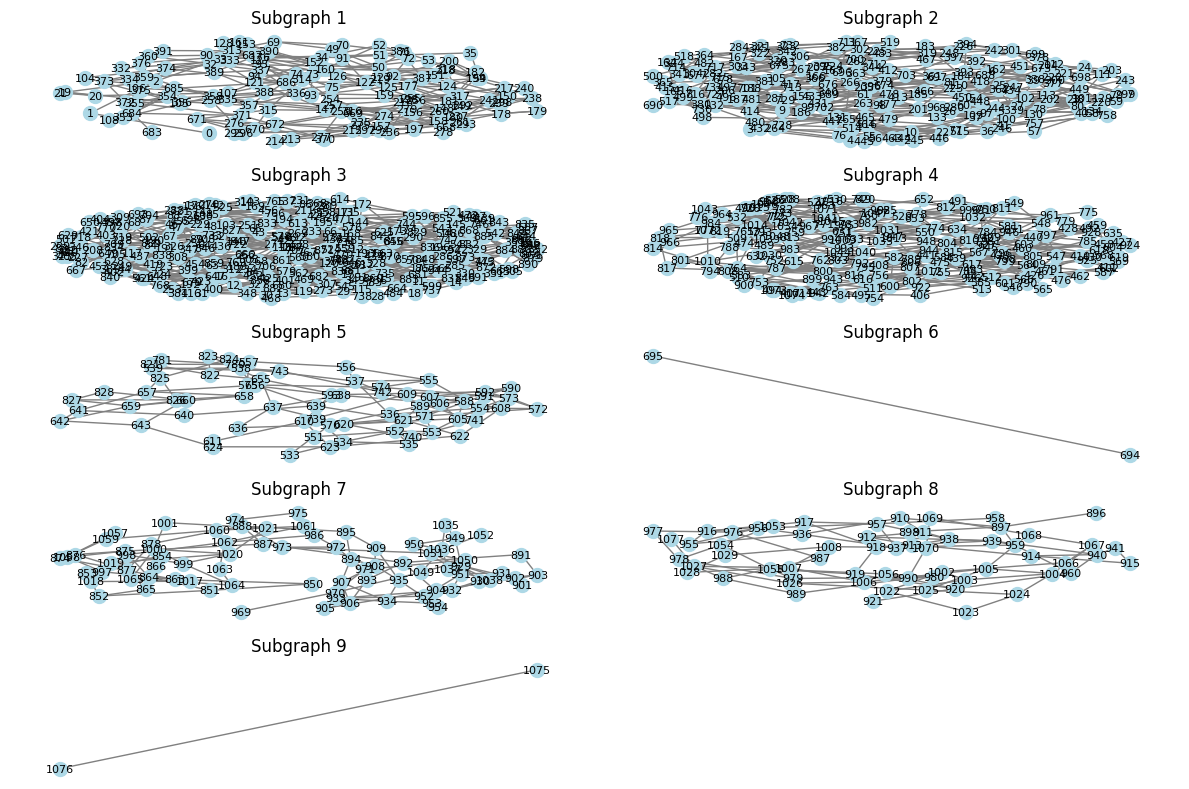

<ipython-input-16-b709971f1773>:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  component = component.append(new_row, ignore_index=True)
<ipython-input-16-b709971f1773>:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  component = component.append(new_row, ignore_index=True)
<ipython-input-16-b709971f1773>:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  component = component.append(new_row, ignore_index=True)
<ipython-input-16-b709971f1773>:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  component = component.append(new_row, ignore_index=True)
<ipython-input-16-b709971f1773>:48: FutureWarning: The frame.append method is deprecated

Thissssss
501


<ipython-input-19-b46bb9ba199d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  component['Visited'][min_idx] = 1
<ipython-input-19-b46bb9ba199d>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  component['Order'][min_idx] = order


In [38]:
image_file = '/content/250.jpg'

pred = doctr_predictions(image_file)

data = {}
json_data = json.dumps(pred)
with open("doctr_file.json", "w") as outfile:
    outfile.write(json_data)

doctr_file = '/content/doctr_file.json'
Reading_Order_Generator(image_file, doctr_file)